# 22 — Freeze + Tier-2: how the recipe was chosen

The [Fang-ViT probe](20_fang_vit_probe.ipynb) showed frozen embeddings pass both
reference gates. This notebook documents the two decisions that turned that into
**the** recipe and its calibrated-abundance sibling — the evidence behind
[PLAN_FM.md](../PLAN_FM.md) §2.1 (head bake-off → freeze) and §2.4 (Tier-2
regression), per DECISIONS.md 2026-06-12 / 2026-06-13.

The arc:
1. **Head bake-off** — *what reads the embedding?* On the identical 768-dim
   matrix, every non-tree head beats LightGBM; the **3-seed MLP ensemble**
   (`mlp_ens3`) wins decisively (paired Wilcoxon). "Trees are the wrong reader of
   a dense embedding."
2. **Freeze** — `mlp_ens3` / GeM(p=3) / **emb-only** / **S=32** / `fa_gt_1e-2`,
   Brian sign-off. The advantage transfers to every non-degenerate target, so the
   target choice is continuity, not necessity.
3. **Tier-2** — the same head as a *regressor* gives calibrated abundance:
   single-stage wins, the two-stage hurdle is dropped, and rich/poor detection is
   preserved. A tail-compression residual remains (a future calibration layer).

Reads banked verdicts/metrics only — nothing is recomputed.


In [1]:
import json
from pathlib import Path
import sys

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
import src.modeling  # noqa: F401  -- Windows DLL bootstrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FIG = REPO / "reports" / "figures"
PROBE = REPO / "models" / "fang_probe"
T2 = REPO / "models" / "fang_tier2"
from src.modeling.evaluate import ABUNDANCE_BIN_LABELS


def load_verdict(label):
    direct = PROBE / label / "verdict.json"
    hits = [direct] if direct.exists() else sorted(PROBE.glob(f"{label}/*/verdict.json"))
    d = json.loads(hits[0].read_text(encoding="utf-8"))
    key = [k for k in d if k != "tier1_ref"][0]
    return key, d[key], d["tier1_ref"]


def load_t2(cell):
    mp = sorted((T2 / cell).glob("*/metrics.json"))[0]
    return json.loads(mp.read_text(encoding="utf-8"))

print("freeze + tier2 artifacts present.")

freeze + tier2 artifacts present.


## 1. Head bake-off — trees are the wrong reader of a dense embedding

Identical feature matrix (768 GeM(p=3) context embeddings, S=64, **no** handcrafted
features), identical LOIO harness, `fa_gt_1e-2`. Only the **head class** differs:
LightGBM (tree) vs logistic regression vs cosine-kNN(50) vs the 3-seed MLP
ensemble. The MLP's pooled calibration is seed-wobbly, so the *ensemble* is the
promotable form (the same lesson as the W2 SmallCNN).


,head,pooled_pr,prec@5%,med_auc,dauc_med(v),win,gate_pooled,gate_per_image
0,lgbm,0.7146,0.8563,0.7571,0.0581,0.5926,True,True
1,logreg,0.7385,0.8901,0.7678,0.1006,0.7778,True,True
2,knn50,0.7709,0.9126,0.7641,0.0926,0.8519,True,True
3,mlp_ens3,0.7852,0.9357,0.8035,0.1374,0.8519,True,True



Paired per-image AUC vs the other heads (Wilcoxon, validity images):
  mlp_ens3-vs-lgbm: median +0.0595  win 0.81  p=1.3e-05  n=27
  mlp_ens3-vs-logreg: median +0.0292  win 0.85  p=0.0006  n=27
  mlp_ens3-vs-knn50: median +0.0499  win 0.70  p=0.0032  n=27


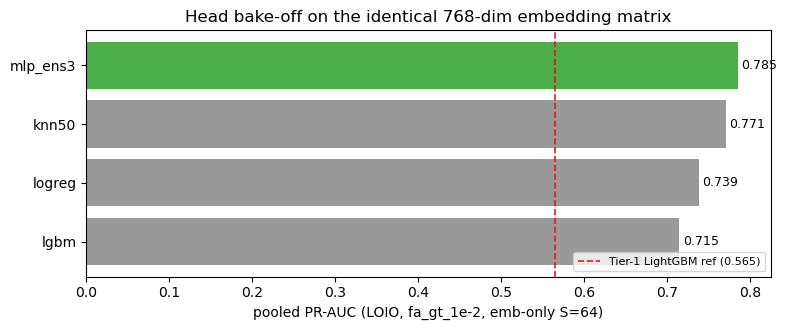

In [2]:
HEADS = ["lgbm", "logreg", "knn50", "mlp_ens3"]
rows, t1ref = [], None
for h in HEADS:
    key, r, ref = load_verdict(f"heads_{h}")
    t1ref = ref["pooled_pr_auc"]
    rows.append({"head": key, "pooled_pr": r["pooled_pr_auc"], "prec@5%": r["prec_at_5"],
                 "med_auc": r["med_auc"], "dauc_med(v)": r.get("dauc_median_v"),
                 "win": r.get("dauc_win_v"), "gate_pooled": r.get("gate_pooled"),
                 "gate_per_image": r.get("gate_per_image")})
bk = pd.DataFrame(rows).sort_values("pooled_pr").reset_index(drop=True)
display(bk.round(4))

pairs = json.loads((PROBE / "head_pairs.json").read_text(encoding="utf-8"))
print("\nPaired per-image AUC vs the other heads (Wilcoxon, validity images):")
for k, v in pairs.items():
    if k.startswith("mlp_ens3-"):
        print(f"  {k}: median {v['median']:+.4f}  win {v['win']:.2f}  p={v['p']:.2g}  n={v['n']}")

fig, ax = plt.subplots(figsize=(8, 3.4))
colors = ["#4daf4a" if h == "mlp_ens3" else "#999999" for h in bk["head"]]
ax.barh(bk["head"], bk["pooled_pr"], color=colors)
ax.axvline(t1ref, color="#e41a1c", ls="--", lw=1.2, label=f"Tier-1 LightGBM ref ({t1ref:.3f})")
for y, v in enumerate(bk["pooled_pr"]):
    ax.text(v + 0.004, y, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlabel("pooled PR-AUC (LOIO, fa_gt_1e-2, emb-only S=64)")
ax.set_title("Head bake-off on the identical 768-dim embedding matrix")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout(); fig.savefig(FIG / "22_head_bakeoff.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. The frozen recipe + target transfer

**Frozen (Brian sign-off):** `mlp_ens3` / GeM(p=3) / **emb-only** / **S=32**
(160 m tiles, 4× finer than S=64) / `fa_gt_1e-2`. At S=32 dropping the handcrafted
features is *free* (emb-only ties t1ctx), so the inference path is embed-and-predict.

The FM advantage is **not** an artifact of the `fa_gt_1e-2` cut: re-read against
each target's OWN Tier-1 baseline, it transfers to every non-degenerate target.
(`bc_ge_1` was the wrong count target — saturated at presence — and is excluded;
the data-grounded `bc_ge_50/100` are shown instead.) The table reports each cell's
pooled PR-AUC vs its own Tier-1 reference; the frozen cell is the S=32 row.


In [3]:
FREEZE_CELLS = [
    ("FROZEN: emb mlp_ens3 S32 fa>1e-2", "fw_emb_mlp_ens3_gem96_S32_fa_gt_1e-2"),
    ("emb mlp_ens3 S64 fa>1e-3",         "fw_emb_mlp_ens3_gem192_S64_fa_gt_1e-3"),
    ("emb mlp_ens3 S64 bc>=50",          "fw_emb_mlp_ens3_gem192_S64_bc_ge_50"),
    ("emb mlp_ens3 S64 bc>=100",         "fw_emb_mlp_ens3_gem192_S64_bc_ge_100"),
    ("t1ctx mlp_ens3 S32 fa>1e-2",       "fw_t1ctx_mlp_ens3_gem96_S32_fa_gt_1e-2"),
]
rows = []
for name, cell in FREEZE_CELLS:
    key, r, ref = load_verdict(cell)
    rows.append({"cell": name, "pooled_pr": r["pooled_pr_auc"], "t1_ref": ref["pooled_pr_auc"],
                 "prec@5%": r["prec_at_5"], "med_auc": r["med_auc"],
                 "dauc_med(v)": r.get("dauc_median_v"),
                 "gate_pooled": r.get("gate_pooled"), "gate_per_image": r.get("gate_per_image")})
ft = pd.DataFrame(rows)
display(ft.round(4))
print("\nEvery cell clears both gates against its OWN Tier-1 -> the FM advantage is "
      "target-definition-robust; fa_gt_1e-2 is frozen for continuity.")

,cell,pooled_pr,t1_ref,prec@5%,med_auc,dauc_med(v),gate_pooled,gate_per_image
0,FROZEN: emb mlp_ens3 S32 fa>1e-2,0.7832,0.4840,0.9476,0.7865,0.1198,True,True
1,emb mlp_ens3 S64 fa>1e-3,0.9088,0.7442,0.9952,0.6937,0.0891,True,True
2,emb mlp_ens3 S64 bc>=50,0.8208,0.6729,0.9721,0.7671,0.1684,True,True
3,emb mlp_ens3 S64 bc>=100,0.7073,0.4219,0.9507,0.7757,0.1351,True,True
4,t1ctx mlp_ens3 S32 fa>1e-2,0.7764,0.4840,0.9319,0.7884,0.1199,True,True



Every cell clears both gates against its OWN Tier-1 -> the FM advantage is target-definition-robust; fa_gt_1e-2 is frozen for continuity.


## 3. Tier-2 — calibrated abundance from the same features

Same emb-only S=32 features, but **regression** (predict *how much*, not just
rich/poor). Three heads (single-stage Tweedie, the two-stage hurdle, and a 3-seed
MLP regressor `mlp_reg`) × {emb, handcrafted t1} × {fractional_area, boulder_count}.
Primary metric is Spearman ρ; `meaningful_auc` is the rich/poor view at the target's
own cut (fa>1e-2 / count≥50).

Verdicts: **`mlp_reg` wins** (MLP is the right reader for regression too); **FM ≈ 2×**
the handcrafted baseline; **single-stage beats the hurdle** (dropped); and the
regressor's rich/poor `meaningful_auc` ≈ the frozen classifier's per-image AUC
(0.7865) — calibrated magnitude comes essentially free.


,head,rho emb.fa,rho t1.fa,rho emb.count,mAUC emb.fa,mAUC emb.count
0,mlp_reg,0.431,0.223,0.386,0.784,0.785
1,tweedie,0.313,0.228,0.286,0.706,0.692
2,two_stage,0.329,0.247,0.308,0.722,0.707


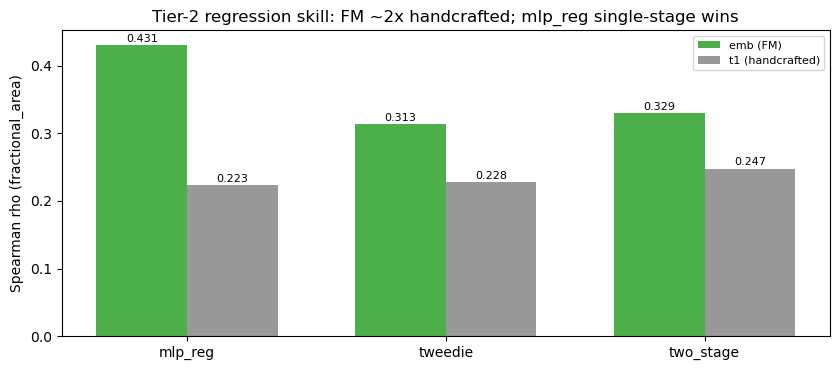

In [4]:
HEADS_T2 = [("mlp_reg", "mlp_reg"), ("lightgbm_tweedie", "tweedie"),
            ("lightgbm_two_stage_balanced", "two_stage")]
def t2_row(head_cell, feat, target):
    agg = load_t2(f"tier2_{head_cell}_{feat}_{target}_S32")["aggregate"]
    return agg["spearman_rho_mean"], agg["meaningful_auc_mean"]

rows = []
for hc, hn in HEADS_T2:
    rows.append({"head": hn,
                 "rho emb.fa": t2_row(hc, "emb", "fractional_area")[0],
                 "rho t1.fa": t2_row(hc, "t1", "fractional_area")[0],
                 "rho emb.count": t2_row(hc, "emb", "boulder_count")[0],
                 "mAUC emb.fa": t2_row(hc, "emb", "fractional_area")[1],
                 "mAUC emb.count": t2_row(hc, "emb", "boulder_count")[1]})
t2 = pd.DataFrame(rows)
display(t2.round(3))

fig, ax = plt.subplots(figsize=(8.5, 3.8))
x = np.arange(len(t2)); w = 0.35
ax.bar(x - w / 2, t2["rho emb.fa"], w, label="emb (FM)", color="#4daf4a")
ax.bar(x + w / 2, t2["rho t1.fa"], w, label="t1 (handcrafted)", color="#999999")
ax.set_xticks(x); ax.set_xticklabels(t2["head"])
ax.set_ylabel("Spearman rho (fractional_area)")
ax.set_title("Tier-2 regression skill: FM ~2x handcrafted; mlp_reg single-stage wins")
for xi, (a, b) in enumerate(zip(t2["rho emb.fa"], t2["rho t1.fa"])):
    ax.text(xi - w / 2, a + 0.005, f"{a:.3f}", ha="center", fontsize=8)
    ax.text(xi + w / 2, b + 0.005, f"{b:.3f}", ha="center", fontsize=8)
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "22_tier2_skill.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. The remaining limiter — dynamic-range compression

The known trap for regression on a zero-inflated, right-skewed target: the model
hedges to the mean and flattens the high-abundance tail. Aggregating the banked
per-bin tables across folds (n-tile-weighted), we plot **predicted vs true mean
abundance per true-abundance bin** for `mlp_reg`. On the dotted identity line the
model would be perfectly calibrated; below it = under-prediction of the tail. The
FM head compresses *less* than the handcrafted head but still under-predicts the
top bin by ~30% — the motivation for a future calibration layer (isotonic /
quantile mapping). Ranking is fine (§3); absolute high-end values are squashed.


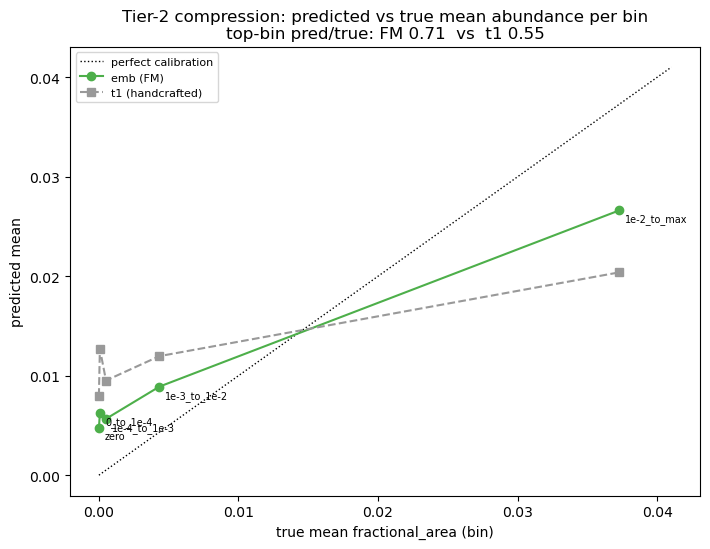

In [5]:
def per_bin_curve(cell):
    pf = load_t2(cell)["per_fold"]
    agg = {lab: {"n": 0, "tp": 0.0, "pp": 0.0} for lab in ABUNDANCE_BIN_LABELS}
    for f in pf:
        for b in f["per_bin_rmse"]:
            n = b["n_tiles"]
            if n and np.isfinite(b["mean_true"]) and np.isfinite(b["mean_pred"]):
                a = agg[b["bin"]]
                a["n"] += n; a["tp"] += n * b["mean_true"]; a["pp"] += n * b["mean_pred"]
    labs = [l for l in ABUNDANCE_BIN_LABELS if agg[l]["n"] > 0]
    mt = np.array([agg[l]["tp"] / agg[l]["n"] for l in labs])
    mp = np.array([agg[l]["pp"] / agg[l]["n"] for l in labs])
    return labs, mt, mp

labs, mt_e, mp_e = per_bin_curve("tier2_mlp_reg_emb_fractional_area_S32")
_, mt_t, mp_t = per_bin_curve("tier2_mlp_reg_t1_fractional_area_S32")

fig, ax = plt.subplots(figsize=(7.2, 5.6))
lim = max(mt_e.max(), mp_e.max(), mp_t.max()) * 1.1
ax.plot([0, lim], [0, lim], "k:", lw=1, label="perfect calibration")
ax.plot(mt_e, mp_e, "o-", color="#4daf4a", label="emb (FM)")
ax.plot(mt_t, mp_t, "s--", color="#999999", label="t1 (handcrafted)")
for x, y, l in zip(mt_e, mp_e, labs):
    ax.annotate(l, (x, y), fontsize=7, xytext=(4, -8), textcoords="offset points")
top = labs[-1]
ax.set_title(f"Tier-2 compression: predicted vs true mean abundance per bin\n"
             f"top-bin pred/true: FM {mp_e[-1]/mt_e[-1]:.2f}  vs  t1 {mp_t[-1]/mt_t[-1]:.2f}")
ax.set_xlabel("true mean fractional_area (bin)"); ax.set_ylabel("predicted mean")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "22_tier2_compression.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Disposition

- **Tier-1 (rich/poor) recipe FROZEN**: `mlp_ens3` / GeM(p=3) / emb-only / S=32 /
  `fa_gt_1e-2` — pooled PR-AUC 0.7832, med per-image AUC 0.7865, both gates pass.
  Productized as the deployable head ([notebook 21](21_map_pilot.ipynb)).
- **Tier-2 (calibrated abundance) candidate**: single-stage `mlp_reg` on the same
  emb-only S=32 features — the hurdle is dropped. Not yet frozen/productized; the
  tail-compression calibration layer is future work.
- **Discipline** (PLAN_FM §3): recipe shopping on the 38 images is closed. The next
  number that touches the recipe is the §2.3 pre-declared confirmation on held-out
  expansion images (waiting on BoulderNet runs over the 23 cohort-expansion ObsIds).
- Standing caveat on every claim: transductive pretraining (the ViT saw test
  *pixels*, never labels); LOIO carries the post-hoc-assembly selection caveat until
  the §2.3 confirmation.

To regenerate: `python notebooks/_build_22.py` then `nbconvert --execute`.
